In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("edirgarcia/tabular-ember")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tabular-ember' dataset.
Path to dataset files: /kaggle/input/tabular-ember


In [14]:
#Loading the dataset to the notebook:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import lightgbm as lgb

# Load the dataset
file_path = '/kaggle/input/tabular-ember/train_features.csv'

# Note: If Colab struggles, add nrows=100000 to the line below to test first
df = pd.read_csv(file_path)

print(f"Initial Shape: {df.shape}")

/tmp/ipykernel_1732/751710798.py:14: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Initial Shape: (800000, 49)


In [15]:
# 1. Check which column is causing the trouble (Column index 5)
problematic_col = df.columns[5]
print(f"Column causing the warning: {problematic_col}")
print(f"Unique values in {problematic_col} (first 5): {df[problematic_col].unique()[:5]}")
# 2. Force everything to numeric, turning errors (strings) into NaN
for col in df.columns:
    if col not in ['label', 'sha256', 'appeared']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
# 3. Handle missing values created by 'coerce' or existing NaNs
df = df.fillna(0)
# 4. Define X and y
# Check if 'label' is the correct name in your 49-column version
target_col = 'label'
X = df.drop(columns=[target_col])
y = df[target_col]
# Drop non-numeric metadata if it still exists (like filenames or hashes)
X = X.select_dtypes(include=[np.number])
print(f"Cleaned Shape: {X.shape}")

Column causing the warning: avclass
Unique values in avclass (first 5): [nan 'sivis' 'upatre' 'startsurf' 'kasidet']
Cleaned Shape: (800000, 46)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the target variable is binary (0 or 1) before splitting
y = y.replace(-1, 0)

# 1. Split the data
# Stratify ensures the ratio of Malware to Benign is the same in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Scale the features
# Important because 'Size' features are much larger than 'Entropy' features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Initialize and Train LightGBM
# This model is specifically optimized for large tabular data
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    boosting_type='gbdt',
    objective='binary',
    random_state=42,
    n_jobs=-1
)

print("Training is starting... With 800k rows, this should take about 1-2 minutes.")
model.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_test_scaled, y_test)],
    eval_metric='binary_logloss'
)
print("Training Complete!")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1120: RuntimeWarning: overflow encountered in square
  temp **= 2
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: overflow encountered in square
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in subtract
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:81: RuntimeWarning: overflow encountered in square
  upper_bound = n_samples * eps * var + (n_samples * mean * eps) ** 2


Training is starting... With 800k rows, this should take about 1-2 minutes.
[LightGBM] [Info] Number of positive: 240000, number of negative: 400000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.103786 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4479
[LightGBM] [Info] Number of data points in the train set: 640000, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375000 -> initscore=-0.510826
[LightGBM] [Info] Start training from score -0.510826
Training Complete!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



   MALWARE DETECTION FINAL RESULTS
              precision    recall  f1-score   support

      Benign       0.93      0.80      0.86    100000
     Malware       0.73      0.89      0.80     60000

    accuracy                           0.84    160000
   macro avg       0.83      0.85      0.83    160000
weighted avg       0.85      0.84      0.84    160000



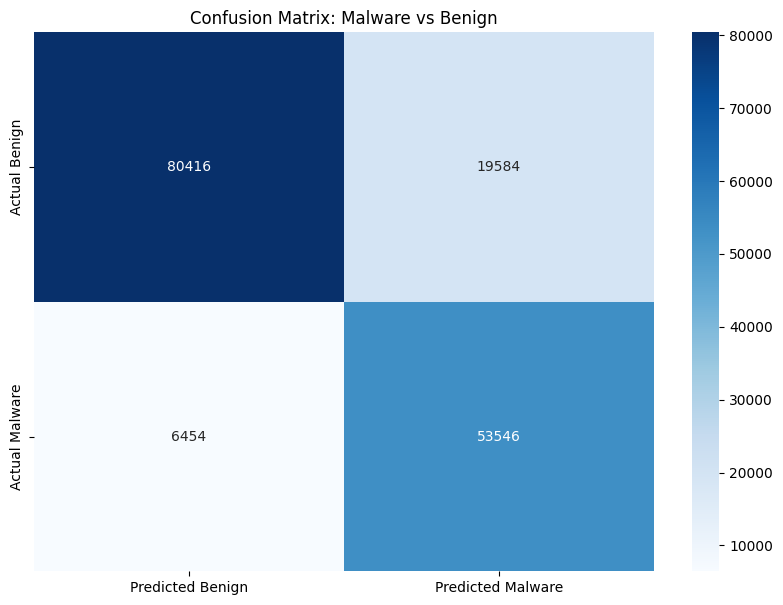


Final ROC-AUC Score: 0.8905


In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 2. Detailed Performance Report
print("\n" + "="*40)
print("   MALWARE DETECTION FINAL RESULTS")
print("="*40)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))

# 3. Plot Confusion Matrix
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
# Calculate percentages for the heatmap
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Benign', 'Predicted Malware'],
            yticklabels=['Actual Benign', 'Actual Malware'])
plt.title('Confusion Matrix: Malware vs Benign')
plt.show()

# 4. Final Score
auc = roc_auc_score(y_test, y_prob)
print(f"\nFinal ROC-AUC Score: {auc:.4f}")

/tmp/ipykernel_626/1167857912.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


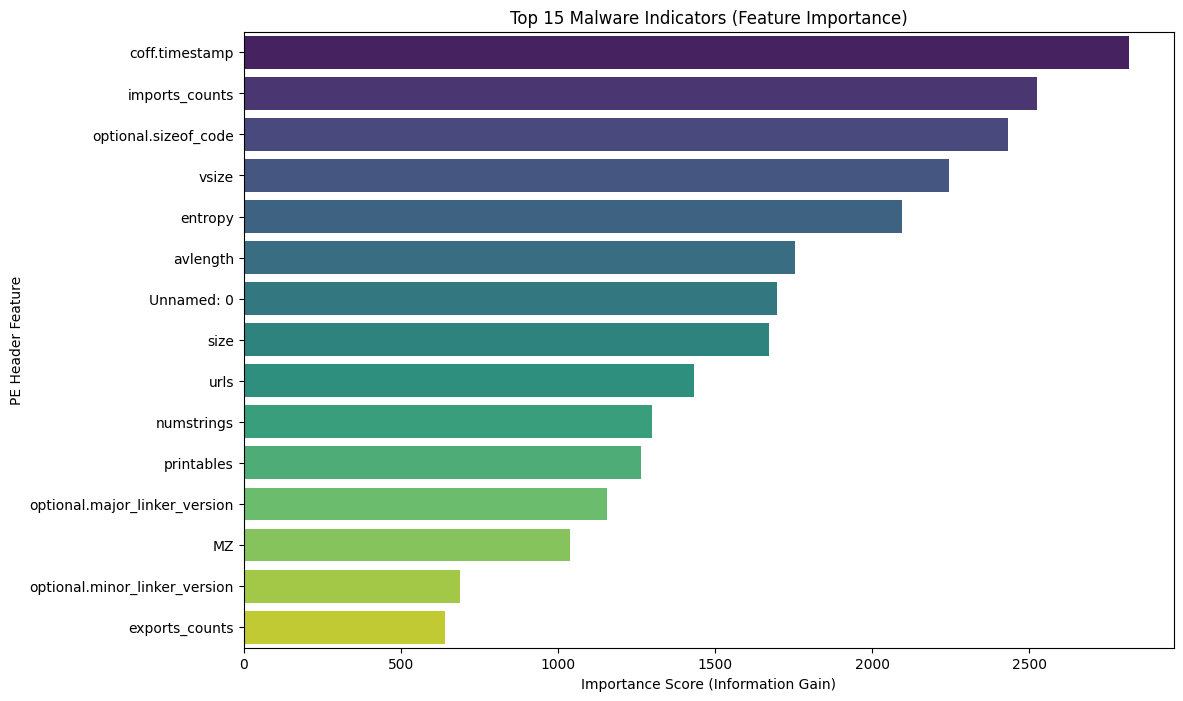

In [11]:
# 1. Get Feature Importance
# Since we lost names during scaling, we map them back
importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 2. Plot Top 15 Features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Malware Indicators (Feature Importance)')
plt.xlabel('Importance Score (Information Gain)')
plt.ylabel('PE Header Feature')
plt.show()

In [18]:
import joblib

# 1. Save the LightGBM model
joblib.dump(model, 'malware_model.pkl')

# 2. Save the Scaler (Crucial for the GUI!)
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and Scaler saved as .pkl files!")

✅ Model and Scaler saved as .pkl files!


In [19]:
from google.colab import files

# Download the trained LightGBM model
files.download('malware_model.pkl')

# Download the scaler (Required for the GUI to process new data)
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>